# MobileViT-XS baseline on ImageNet-100

Training MobileViT-XS from scratch as the matched-protocol control for the CBA-MobileViT-S-lite comparison.

**Why MobileViT-XS:** same v1 family lineage as CBA (derives from MobileViT-S), no knowledge distillation in the published recipe, size-matched at 2.3M params / ~1.05G MACs vs CBA-lite's 2.8M / 1.1G.

**Recipe (matched to CBA-lite):** 256x256, 50 epochs, AdamW decoupled WD, B=512, LR=1.5e-3, cosine + 10-epoch warmup, RandAugment(N=2, M=9), Mixup(0.2)/CutMix(1.0) p=0.5, drop_path=0.05, EMA decay=0.995, bf16 AMP.

In [1]:
import os, math, time, json, copy, csv
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler

import torchvision
import torchvision.transforms as T

import timm
from datasets import load_dataset
from tqdm.auto import tqdm

# inline so the results figure is embedded in the saved notebook
%matplotlib inline
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

print(f'PyTorch : {torch.__version__}')
print(f'CUDA    : {torch.version.cuda}')
print(f'GPU     : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "not available"}')
if torch.cuda.is_available():
    print(f'bf16 supported: {torch.cuda.is_bf16_supported()}')

PyTorch : 2.10.0+cu128
CUDA    : 12.8
GPU     : NVIDIA RTX PRO 6000 Blackwell Server Edition
bf16 supported: True


In [2]:
# mount Drive so checkpoints and logs survive across Colab sessions
from google.colab import drive
drive.mount('/content/drive')

_drive_out = Path('/content/drive/MyDrive/colab/baselines')
_drive_out.mkdir(parents=True, exist_ok=True)
print(f'Output directory : {_drive_out}  (exists: {_drive_out.exists()})')

Mounted at /content/drive
Output directory : /content/drive/MyDrive/colab/baselines  (exists: True)


In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

CFG = {
    # MobileViT-XS via timm, random init
    'model_name'         : 'mobilevit_xs',

    # training — matched to CBA-lite byte-for-byte
    'epochs'             : 50,
    'batch_size'         : 512,
    'num_workers'        : 8,
    'num_classes'        : 100,
    'img_size'           : 256,

    # optimizer
    # 1.5e-3 matches CBA-lite: between sqrt-scaling (1.13e-3) and linear (3.2e-3) from B=64 reference
    'lr'                 : 1.5e-3,
    'weight_decay'       : 0.05,
    'grad_clip'          : 1.0,

    'warmup_epochs'      : 10,

    'label_smoothing'    : 0.1,

    # augmentation
    'randaug_n'          : 2,
    'randaug_m'          : 9,
    'mixup_alpha'        : 0.2,
    'cutmix_alpha'       : 1.0,
    'mixup_prob'         : 0.5,
    'mixup_switch'       : 0.5,

    # regularization
    'drop_path_rate'     : 0.05,
    'ema_decay'          : 0.995,

    'device'             : device,

    # bf16 on Ampere+; falls back to fp16 + GradScaler on Turing
    'amp'                : True,
    'amp_dtype'          : 'bf16',

    'save_dir'           : Path('/content/drive/MyDrive/colab/baselines'),
    'run_name'           : 'mobilevit_xs_in100_fromscratch',
    'seed'               : 42,
}

CFG['save_dir'].mkdir(parents=True, exist_ok=True)
torch.manual_seed(CFG['seed'])
print(f'Training on: {device}')

Training on: cuda


In [4]:
_MEAN = (0.485, 0.456, 0.406)
_STD  = (0.229, 0.224, 0.225)


def _build_transforms(cfg):
    train_tf = T.Compose([
        T.RandomResizedCrop(cfg['img_size'], scale=(0.08, 1.0)),
        T.RandomHorizontalFlip(),
        T.RandAugment(num_ops=cfg['randaug_n'], magnitude=cfg['randaug_m']),
        T.ToTensor(),
        T.Normalize(_MEAN, _STD),
    ])
    val_tf = T.Compose([
        T.Resize(int(cfg['img_size'] / 0.875)),
        T.CenterCrop(cfg['img_size']),
        T.ToTensor(),
        T.Normalize(_MEAN, _STD),
    ])
    return train_tf, val_tf


class HFImageDataset(Dataset):
    def __init__(self, hf_split, transform):
        self.ds = hf_split
        self.tf = transform

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        item = self.ds[idx]
        return self.tf(item['image'].convert('RGB')), item['label']


print('Loading ImageNet-100 from HuggingFace (warming cache)...')
_warm = load_dataset('clane9/imagenet-100')
print(f"Train size : {len(_warm['train'])}")
print(f"Val size   : {len(_warm['validation'])}")
del _warm

Loading ImageNet-100 from HuggingFace (warming cache)...


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

data/train-00000-of-00017.parquet:   0%|          | 0.00/505M [00:00<?, ?B/s]

...

data/validation-00000-of-00001.parquet:   0%|          | 0.00/314M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/126689 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5000 [00:00<?, ? examples/s]

Loading dataset shards:   0%|          | 0/17 [00:00<?, ?it/s]

Train size : 126689
Val size   : 5000


## Model: MobileViT-XS (random init via timm)

CPU-side sanity check verifying the model builds and produces the right output shape before training starts.

In [5]:
# sanity check before training: model builds with the correct output shape
_model_cpu = timm.create_model(
    CFG['model_name'],
    pretrained=False,
    num_classes=CFG['num_classes'],
    drop_path_rate=CFG['drop_path_rate'],
)
total_params = sum(p.numel() for p in _model_cpu.parameters())
print(f'Model               : {CFG["model_name"]} (random init, no pretrained weights)')
print(f'Total parameters    : {total_params:>12,}')

_model_cpu.eval()
with torch.no_grad():
    _dummy = torch.zeros(2, 3, CFG['img_size'], CFG['img_size'])
    _out   = _model_cpu(_dummy)
print(f'Forward pass: {tuple(_dummy.shape)} -> {tuple(_out.shape)}')
assert _out.shape == (2, CFG['num_classes']), \
    f'Expected (2, {CFG["num_classes"]}), got {_out.shape}'
print('Shape check passed')
del _model_cpu, _dummy, _out

Model               : mobilevit_xs (random init, no pretrained weights)
Total parameters    :    1,971,348
Forward pass: (2, 3, 256, 256) → (2, 100)
Shape check passed ✓


## GPU Training

Single-GPU loop, bf16 autocast, same recipe as CBA-MobileViT-S-lite. Only the architecture differs between the two runs.

In [6]:
# applies Mixup or CutMix per batch (50/50 given switch_prob, with overall prob `prob`)
# returns (imgs, label_a, label_b, lambda) for the mixed CE loss
class MixupCutmix:
    def __init__(self, mixup_alpha=0.2, cutmix_alpha=1.0, prob=0.5, switch_prob=0.5):
        self.mixup_alpha = mixup_alpha
        self.cutmix_alpha = cutmix_alpha
        self.prob = prob
        self.switch_prob = switch_prob

    def __call__(self, imgs, labels):
        if torch.rand(1).item() >= self.prob:
            return imgs, labels, labels, 1.0
        idx = torch.randperm(imgs.size(0), device=imgs.device)
        if torch.rand(1).item() < self.switch_prob:
            lam = float(np.random.beta(self.cutmix_alpha, self.cutmix_alpha))
            H, W = imgs.shape[2], imgs.shape[3]
            cut_rat = math.sqrt(1.0 - lam)
            cut_w, cut_h = int(W * cut_rat), int(H * cut_rat)
            cx, cy = np.random.randint(W), np.random.randint(H)
            x1, y1 = max(0, cx - cut_w // 2), max(0, cy - cut_h // 2)
            x2, y2 = min(W, cx + cut_w // 2), min(H, cy + cut_h // 2)
            imgs[:, :, y1:y2, x1:x2] = imgs[idx, :, y1:y2, x1:x2]
            lam = 1.0 - ((x2 - x1) * (y2 - y1) / float(W * H))
        else:
            lam = float(np.random.beta(self.mixup_alpha, self.mixup_alpha))
            imgs = lam * imgs + (1.0 - lam) * imgs[idx]
        return imgs, labels, labels[idx], lam


# exponential moving average of model weights; BN buffers are copied not averaged
class ModelEMA:
    def __init__(self, model, decay=0.9995):
        self.module = copy.deepcopy(model).eval()
        for p in self.module.parameters():
            p.requires_grad_(False)
        self.decay = decay

    @torch.no_grad()
    def update(self, model):
        d = self.decay
        msd = model.state_dict()
        for k, v in self.module.state_dict().items():
            if v.dtype.is_floating_point:
                v.mul_(d).add_(msd[k].detach(), alpha=1.0 - d)
            else:
                v.copy_(msd[k])


# weight decay on conv/linear weights only, skips BN, LN and biases
def build_param_groups(model, weight_decay):
    decay, no_decay = [], []
    for n, p in model.named_parameters():
        if not p.requires_grad:
            continue
        if p.ndim <= 1 or n.endswith('.bias'):
            no_decay.append(p)
        else:
            decay.append(p)
    return [
        {'params': decay,    'weight_decay': weight_decay},
        {'params': no_decay, 'weight_decay': 0.0},
    ]


def _amp_dtype(cfg):
    return torch.bfloat16 if cfg.get('amp_dtype', 'bf16') == 'bf16' else torch.float16


# one training epoch with Mixup/CutMix and EMA update
# returns (loss, acc1_pct, elapsed_s); accuracy is in [0,100] to match CBA-lite CSV format
def train_one_epoch_gpu(model, loader, criterion, optimizer, scaler, mixup, ema, cfg, device, epoch):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    t0 = time.time()
    use_bf16 = cfg.get('amp_dtype', 'bf16') == 'bf16'
    dtype = _amp_dtype(cfg)

    for images, labels in tqdm(loader, desc=f'Train {epoch+1:>3}', leave=False):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        images, y_a, y_b, lam = mixup(images, labels)

        optimizer.zero_grad(set_to_none=True)

        with autocast('cuda', dtype=dtype, enabled=cfg['amp']):
            logits = model(images)
            loss   = lam * criterion(logits, y_a) + (1.0 - lam) * criterion(logits, y_b)

        if use_bf16:
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), cfg['grad_clip'])
            optimizer.step()
        else:
            # fp16 path needs GradScaler for dynamic loss scaling
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), cfg['grad_clip'])
            scaler.step(optimizer)
            scaler.update()

        if ema is not None:
            ema.update(model)

        bs          = images.size(0)
        total_loss += loss.item() * bs
        correct    += (logits.argmax(1) == y_a).sum().item()
        total      += bs

    return total_loss / total, 100.0 * correct / total, time.time() - t0


@torch.no_grad()
def evaluate_gpu(model, loader, criterion, device, cfg):
    # returns (loss, top1_pct, top5_pct) in [0,100]
    model.eval()
    total_loss, c1, c5, total = 0.0, 0, 0, 0
    dtype = _amp_dtype(cfg)

    for images, labels in tqdm(loader, desc='  Val    ', leave=False):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        with autocast('cuda', dtype=dtype, enabled=cfg['amp']):
            logits = model(images)
            loss   = criterion(logits, labels)
        bs          = images.size(0)
        total_loss += loss.item() * bs
        c1         += (logits.argmax(1) == labels).sum().item()
        _, top5     = logits.topk(min(5, logits.size(1)), dim=1)
        c5         += (top5 == labels.unsqueeze(1)).any(1).sum().item()
        total      += bs

    return total_loss / total, 100.0 * c1 / total, 100.0 * c5 / total


def measure_throughput_gpu(model, input_size, device, batch_size=64, n_warmup=20, n_runs=100, cfg=None):
    model.eval()
    dummy = torch.randn(batch_size, 3, *input_size, device=device)
    dtype = _amp_dtype(cfg) if cfg is not None else torch.float16

    for _ in range(n_warmup):
        with autocast('cuda', dtype=dtype):
            _ = model(dummy)
    torch.cuda.synchronize()

    t0 = time.perf_counter()
    for _ in range(n_runs):
        with autocast('cuda', dtype=dtype):
            _ = model(dummy)
    torch.cuda.synchronize()
    elapsed = time.perf_counter() - t0
    return (batch_size * n_runs) / elapsed


def run_training_gpu(model_name, timm_name, cfg):
    # train from scratch on a single GPU, return history dict
    device = cfg['device']

    import gc
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()
        _alloc = torch.cuda.memory_allocated() / 1e9
        _resvd = torch.cuda.memory_reserved()  / 1e9
        print(f'GPU after cleanup: {_alloc:.2f} GB allocated, {_resvd:.2f} GB reserved')

    if cfg.get('amp_dtype', 'bf16') == 'bf16' and torch.cuda.is_available() \
            and not torch.cuda.is_bf16_supported():
        print("WARNING: bf16 requested but not supported on this GPU, falling back to fp16")
        cfg['amp_dtype'] = 'fp16'

    model = timm.create_model(
        timm_name,
        pretrained=False,
        num_classes=cfg['num_classes'],
        drop_path_rate=cfg['drop_path_rate'],
    )
    model = model.to(device)

    input_size = (cfg['img_size'], cfg['img_size'])
    n_params   = sum(p.numel() for p in model.parameters()) / 1e6

    print(f'\n{"=" * 60}')
    print(f'  Model : {model_name}  ({timm_name})  on {device}')
    print(f'{"=" * 60}')
    print(f'  Random init      : pretrained=False')
    print(f'  Input size       : {input_size}')
    print(f'  Params (total)   : {n_params:.2f}M')
    print(f'  Batch size       : {cfg["batch_size"]}')
    print(f'  Epochs           : {cfg["epochs"]}')
    print(f'  AMP              : {cfg["amp"]}  ({cfg.get("amp_dtype", "bf16")})')

    train_tf, val_tf = _build_transforms(cfg)
    hf_dataset = load_dataset('clane9/imagenet-100')
    train_ds   = HFImageDataset(hf_dataset['train'],      train_tf)
    val_ds     = HFImageDataset(hf_dataset['validation'], val_tf)

    _pw = cfg['num_workers'] > 0
    train_loader = DataLoader(
        train_ds, batch_size=cfg['batch_size'], shuffle=True,
        num_workers=cfg['num_workers'], drop_last=True,
        persistent_workers=_pw, pin_memory=True,
        prefetch_factor=4 if _pw else None,
    )
    val_loader = DataLoader(
        val_ds, batch_size=cfg['batch_size'] * 2, shuffle=False,
        num_workers=cfg['num_workers'], drop_last=False,
        persistent_workers=_pw, pin_memory=True,
        prefetch_factor=4 if _pw else None,
    )

    criterion = nn.CrossEntropyLoss(label_smoothing=cfg['label_smoothing'])
    optimizer = optim.AdamW(
        build_param_groups(model, cfg['weight_decay']),
        lr=cfg['lr'], betas=(0.9, 0.999),
    )

    # GradScaler only on the fp16 path
    if cfg.get('amp_dtype', 'bf16') == 'fp16':
        scaler = GradScaler('cuda', enabled=cfg.get('amp', True))
    else:
        scaler = None

    mixup  = MixupCutmix(
        mixup_alpha=cfg['mixup_alpha'],
        cutmix_alpha=cfg['cutmix_alpha'],
        prob=cfg['mixup_prob'],
        switch_prob=cfg['mixup_switch'],
    )
    ema = ModelEMA(model, decay=cfg['ema_decay'])

    def _lr_lambda(ep):
        # linear warmup then cosine decay
        if ep < cfg['warmup_epochs']:
            return (ep + 1) / cfg['warmup_epochs']
        t = (ep - cfg['warmup_epochs']) / max(1, cfg['epochs'] - cfg['warmup_epochs'])
        return 0.5 * (1.0 + math.cos(math.pi * t))

    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, _lr_lambda)

    n_decay   = sum(p.numel() for p in optimizer.param_groups[0]['params'])
    n_nodecay = sum(p.numel() for p in optimizer.param_groups[1]['params'])
    print(f'  Optim            : AdamW lr={cfg["lr"]} wd={cfg["weight_decay"]} '
          f'(decay={n_decay:,}, no-decay={n_nodecay:,})')
    print(f'  Sched            : Cosine, warmup={cfg["warmup_epochs"]} ep')
    print(f'  Aug              : RandAug(N={cfg["randaug_n"]}, M={cfg["randaug_m"]}) + '
          f'Mixup({cfg["mixup_alpha"]})/CutMix({cfg["cutmix_alpha"]}) p={cfg["mixup_prob"]}')
    print(f'  Reg              : drop_path={cfg["drop_path_rate"]} EMA decay={cfg["ema_decay"]}')

    log_path = cfg['save_dir'] / f"{cfg['run_name']}_log.csv"
    with open(log_path, 'w', newline='') as f:
        csv.writer(f).writerow([
            'epoch', 'train_loss', 'train_acc1',
            'val_loss',     'val_acc1',     'val_acc5',
            'ema_val_loss', 'ema_val_acc1', 'ema_val_acc5',
            'lr', 'time_s',
        ])
    print(f'  Log              : {log_path}')

    history = {'epoch': [], 'train_loss': [], 'train_acc1': [],
               'val_loss': [], 'val_acc1': [], 'val_acc5': [],
               'ema_val_loss': [], 'ema_val_acc1': [], 'ema_val_acc5': [],
               'lr': []}
    best_acc   = 0.0
    best_ckpt  = cfg['save_dir'] / f"{cfg['run_name']}_best.pth"
    final_ckpt = cfg['save_dir'] / f"{cfg['run_name']}_final.pth"

    for epoch in range(cfg['epochs']):
        t_loss, t_acc, t_time = train_one_epoch_gpu(
            model, train_loader, criterion, optimizer, scaler, mixup, ema, cfg, device, epoch)
        v_loss,  v_acc1,  v_acc5  = evaluate_gpu(model,      val_loader, criterion, device, cfg)
        ev_loss, ev_acc1, ev_acc5 = evaluate_gpu(ema.module, val_loader, criterion, device, cfg)
        scheduler.step()

        cur_lr     = scheduler.get_last_lr()[0]
        epoch_best = max(v_acc1, ev_acc1)
        if epoch_best > best_acc:
            best_acc = epoch_best
            torch.save({
                'model_name'     : timm_name,
                'num_classes'    : cfg['num_classes'],
                'state_dict'     : model.state_dict(),
                'ema_state_dict' : ema.module.state_dict(),
                'epoch'          : epoch + 1,
                'val_acc1'       : v_acc1,
                'ema_val_acc1'   : ev_acc1,
            }, best_ckpt)

        history['epoch'].append(epoch + 1)
        history['train_loss'].append(t_loss)
        history['train_acc1'].append(t_acc)
        history['val_loss'].append(v_loss)
        history['val_acc1'].append(v_acc1)
        history['val_acc5'].append(v_acc5)
        history['ema_val_loss'].append(ev_loss)
        history['ema_val_acc1'].append(ev_acc1)
        history['ema_val_acc5'].append(ev_acc5)
        history['lr'].append(cur_lr)

        # append to CSV incrementally so a mid-run crash still leaves a usable log
        with open(log_path, 'a', newline='') as f:
            csv.writer(f).writerow([
                epoch + 1, f'{t_loss:.4f}', f'{t_acc:.2f}',
                f'{v_loss:.4f}',  f'{v_acc1:.2f}',  f'{v_acc5:.2f}',
                f'{ev_loss:.4f}', f'{ev_acc1:.2f}', f'{ev_acc5:.2f}',
                f'{cur_lr:.6f}', f'{t_time:.1f}',
            ])

        print(f'E{epoch+1:>3}/{cfg["epochs"]}  '
              f'tr_loss={t_loss:.4f}  tr_acc={t_acc:5.2f}  '
              f'val={v_acc1:5.2f}/{v_acc5:5.2f}  '
              f'ema={ev_acc1:5.2f}/{ev_acc5:5.2f}  '
              f'best={best_acc:5.2f}  lr={cur_lr:.2e}  t={t_time:.0f}s')

    torch.save({
        'model_name'     : timm_name,
        'num_classes'    : cfg['num_classes'],
        'state_dict'     : model.state_dict(),
        'ema_state_dict' : ema.module.state_dict(),
        'epoch'          : cfg['epochs'],
        'val_acc1'       : v_acc1,
        'ema_val_acc1'   : ev_acc1,
    }, final_ckpt)

    throughput = measure_throughput_gpu(model, input_size, device, batch_size=cfg['batch_size'], cfg=cfg)
    print(f'\n  Best val acc     : {best_acc:.2f}%  (live or EMA)')
    print(f'  Throughput       : {throughput:.0f} img/s')
    print(f'  Best ckpt        : {best_ckpt}')
    print(f'  Final ckpt       : {final_ckpt}')

    history['best_val_acc'] = best_acc
    history['throughput']   = throughput
    history['model_name']   = model_name
    history['input_size']   = list(input_size)
    history['params_M']     = n_params

    with open(cfg['save_dir'] / f"{cfg['run_name']}_history.json", 'w') as f:
        json.dump(history, f, indent=2)

    return history

In [7]:
history = run_training_gpu(CFG['model_name'], CFG['model_name'], CFG)

GPU after cleanup: 0.00 GB allocated, 0.00 GB reserved

  Model : mobilevit_xs  (mobilevit_xs)  on cuda
  Random init      : pretrained=False
  Input size       : (256, 256)
  Params (total)   : 1.97M
  Batch size       : 512
  Epochs           : 50
  AMP              : True  (bf16)


Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/17 [00:00<?, ?it/s]

  Optim            : AdamW lr=0.0015 wd=0.05 (decay=1,949,936, no-decay=21,412)
  Sched            : Cosine, warmup=10 ep
  Aug              : RandAug(N=2, M=9) + Mixup(0.2)/CutMix(1.0) p=0.5
  Reg              : drop_path=0.05 EMA decay=0.995
  Log              : /content/drive/MyDrive/colab/baselines/mobilevit_xs_in100_fromscratch_log.csv


...

E 49/50  tr_loss=2.4204  tr_acc=50.56  val=76.90/94.50  ema=76.82/94.54  best=76.90  lr=2.31e-06  t=106s


Train  50:   0%|          | 0/247 [00:00<?, ?it/s]

  Val    :   0%|          | 0/5 [00:00<?, ?it/s]

  Val    :   0%|          | 0/5 [00:00<?, ?it/s]

E 50/50  tr_loss=2.3646  tr_acc=52.52  val=76.78/94.52  ema=76.78/94.52  best=76.90  lr=0.00e+00  t=106s

  Best val acc     : 76.90%  (live or EMA)
  Throughput       : 5724 img/s
  Best ckpt        : /content/drive/MyDrive/colab/baselines/mobilevit_xs_in100_fromscratch_best.pth
  Final ckpt       : /content/drive/MyDrive/colab/baselines/mobilevit_xs_in100_fromscratch_final.pth


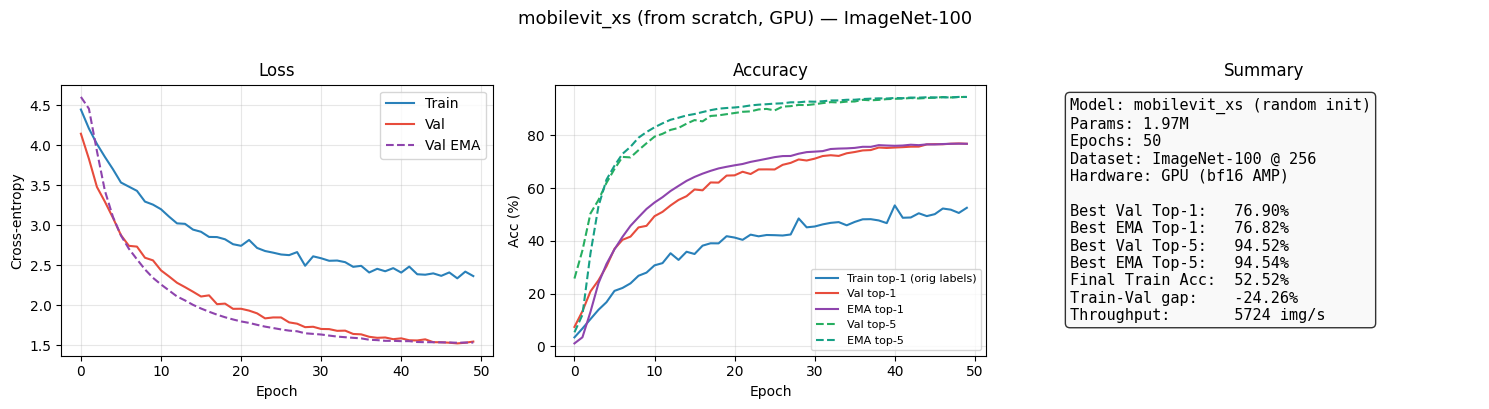

Saved /content/drive/MyDrive/colab/baselines/mobilevit_xs_in100_fromscratch_results.png


In [8]:
# accuracies stored in [0,100] — no *100 conversion needed here
axes[1].plot(history['train_acc1'],   label='Train top-1 (orig labels)', color='#2980b9', lw=1.5)
axes[1].plot(history['val_acc1'],     label='Val top-1',                 color='#e74c3c', lw=1.5)
axes[1].plot(history['ema_val_acc1'], label='EMA top-1',                 color='#8e44ad', lw=1.5)
axes[1].plot(history['val_acc5'],     label='Val top-5',                 color='#27ae60', lw=1.5, ls='--')
axes[1].plot(history['ema_val_acc5'], label='EMA top-5',                 color='#16a085', lw=1.5, ls='--')
axes[1].set(title='Accuracy', xlabel='Epoch', ylabel='Acc (%)')
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)

ax = axes[2]
ax.axis('off')
summary = [
    f'Model: {CFG["model_name"]} (random init)',
    f'Params: {history.get("params_M", 0):.2f}M',
    f'Epochs: {CFG["epochs"]}',
    f'Dataset: ImageNet-100 @ {CFG["img_size"]}',
    f'Hardware: GPU ({CFG.get("amp_dtype", "bf16")} AMP)',
    f'',
    f'Best Val Top-1:   {max(history["val_acc1"]):.2f}%',
    f'Best EMA Top-1:   {max(history["ema_val_acc1"]):.2f}%',
    f'Best Val Top-5:   {max(history["val_acc5"]):.2f}%',
    f'Best EMA Top-5:   {max(history["ema_val_acc5"]):.2f}%',
    f'Final Train Acc:  {history["train_acc1"][-1]:.2f}%',
    f'Train-Val gap:    {history["train_acc1"][-1] - history["val_acc1"][-1]:+.2f}%',
    f'Throughput:       {history.get("throughput", 0):.0f} img/s',
]
ax.text(0.05, 0.95, '\n'.join(summary), transform=ax.transAxes,
        va='top', fontsize=11, family='monospace',
        bbox=dict(boxstyle='round', facecolor='#f8f8f8', alpha=0.8))
ax.set_title('Summary')

plt.suptitle(f'{CFG["model_name"]} (from scratch, GPU) — ImageNet-100', fontsize=13, y=1.01)
plt.tight_layout()
out_fig = CFG['save_dir'] / f"{CFG['run_name']}_results.png"
plt.savefig(out_fig, dpi=120, bbox_inches='tight')
plt.show()
print(f'Saved {out_fig}')

---
## Loading the saved checkpoint

```python
import torch, timm

ckpt = torch.load('/content/drive/MyDrive/colab/baselines/mobilevit_xs_in100_fromscratch_best.pth',
                  map_location='cpu')
model = timm.create_model(ckpt['model_name'], pretrained=False, num_classes=ckpt['num_classes'])
model.load_state_dict(ckpt['ema_state_dict'])  # use ema_state_dict for inference
model.eval()
```

Two checkpoints are saved: `_best.pth` (highest live-or-EMA val top-1 during training) and `_final.pth` (last epoch). Use `_best.pth` for inference, `_final.pth` if continuing training.